In [11]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
from pathlib import Path

 

outdir_sim2 = Path(
    r"C:/Document/Serieux/Travail/Data_analysis_and_papers/benchmark_cebmf/cEBMF_sim_and_fit/ind"
) 
 
 
# Reproducibility
from cebmf_torch import cEBMF

[CGB] Epoch 10/10, Loss=1.8535, mu2=0.028, sigma2=1.642
[CGB] Epoch 10/10, Loss=1.8325, mu2=-0.012, sigma2=1.682
[CGB] Epoch 10/10, Loss=1.8083, mu2=0.006, sigma2=1.804
[CGB] Epoch 10/10, Loss=1.8135, mu2=0.015, sigma2=1.718
[CGB] Epoch 10/10, Loss=1.8057, mu2=0.001, sigma2=1.699
[CGB] Epoch 10/10, Loss=1.7933, mu2=-0.006, sigma2=1.726
[CGB] Epoch 10/10, Loss=1.7843, mu2=0.018, sigma2=1.762
[CGB] Epoch 10/10, Loss=1.7866, mu2=0.046, sigma2=1.857
[CGB] Epoch 10/10, Loss=1.7812, mu2=-0.029, sigma2=1.891
[CGB] Epoch 10/10, Loss=1.7535, mu2=0.014, sigma2=2.092
[CGB] Epoch 10/10, Loss=1.7588, mu2=0.053, sigma2=2.055
[CGB] Epoch 10/10, Loss=1.7413, mu2=0.013, sigma2=2.014
[CGB] Epoch 10/10, Loss=1.7071, mu2=-0.007, sigma2=2.198
[CGB] Epoch 10/10, Loss=1.7223, mu2=0.030, sigma2=2.298
[CGB-2] Epoch 10/10, Loss=2.2146, mu_pos=0.726, mu_neg=-0.722, sigma1=0.157, sigma2=0.167
[CGB-2] Epoch 10/10, Loss=2.2150, mu_pos=0.722, mu_neg=-0.723, sigma1=0.154, sigma2=0.170
[CGB-2] Epoch 10/10, Loss=2.1254

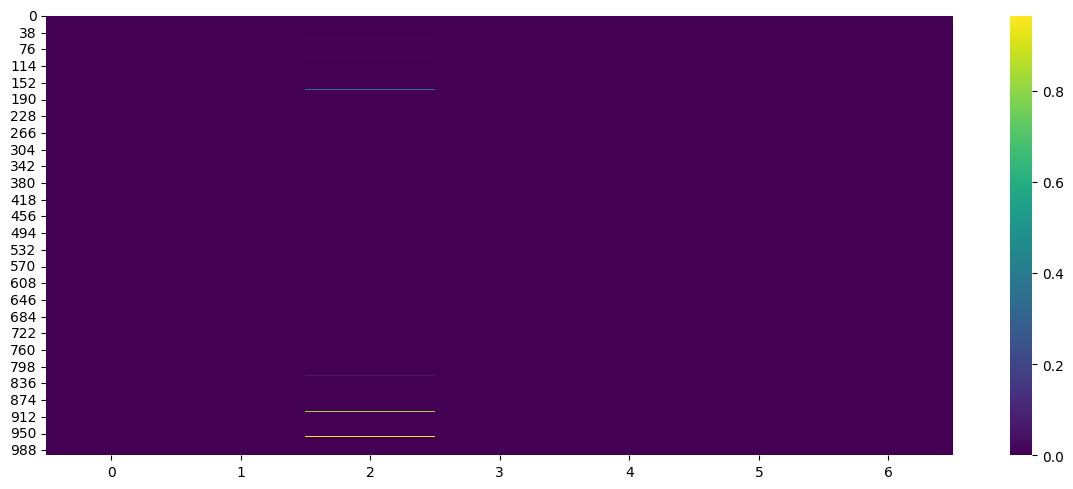

[CGB] Epoch 10/10, Loss=1.8366, mu2=-0.034, sigma2=1.767
[CGB] Epoch 10/10, Loss=1.8316, mu2=-0.031, sigma2=1.752
[CGB] Epoch 10/10, Loss=1.8265, mu2=-0.010, sigma2=1.684
[CGB] Epoch 10/10, Loss=1.8216, mu2=-0.031, sigma2=1.597
[CGB] Epoch 10/10, Loss=1.8083, mu2=-0.018, sigma2=1.667
[CGB] Epoch 10/10, Loss=1.7948, mu2=0.020, sigma2=1.657
[CGB] Epoch 10/10, Loss=1.7921, mu2=0.020, sigma2=1.646
[CGB] Epoch 10/10, Loss=1.7753, mu2=-0.067, sigma2=1.941
[CGB] Epoch 10/10, Loss=1.7800, mu2=-0.054, sigma2=1.972
[CGB] Epoch 10/10, Loss=1.7705, mu2=-0.014, sigma2=1.972
[CGB] Epoch 10/10, Loss=1.7512, mu2=-0.041, sigma2=1.870
[CGB] Epoch 10/10, Loss=1.7463, mu2=-0.045, sigma2=1.997
[CGB] Epoch 10/10, Loss=1.7224, mu2=0.032, sigma2=2.091
[CGB] Epoch 10/10, Loss=1.7296, mu2=0.040, sigma2=1.974
[CGB-2] Epoch 10/10, Loss=2.1871, mu_pos=0.723, mu_neg=-0.724, sigma1=0.219, sigma2=0.247
[CGB-2] Epoch 10/10, Loss=2.2367, mu_pos=0.725, mu_neg=-0.725, sigma1=0.185, sigma2=0.268
[CGB-2] Epoch 10/10, Loss=

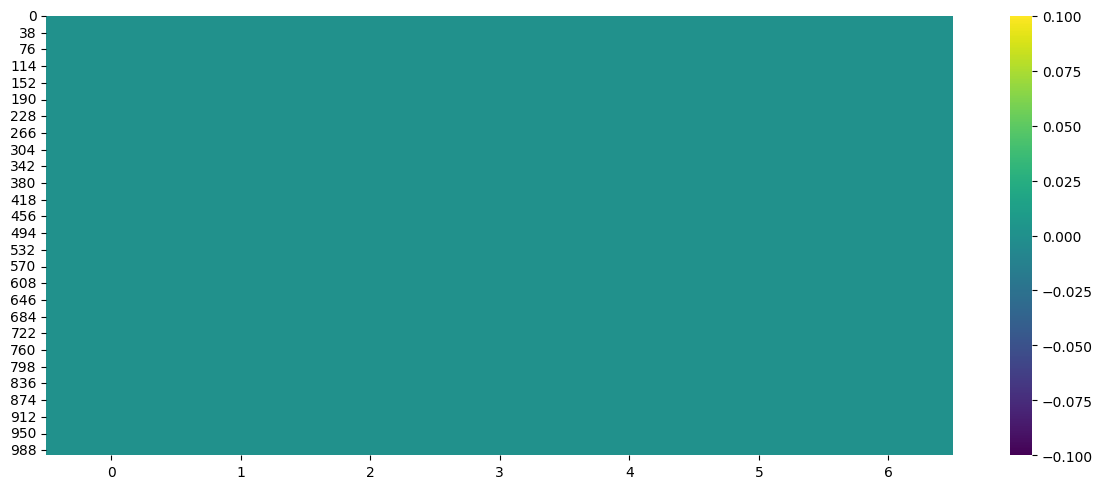

[CGB] Epoch 10/10, Loss=1.8526, mu2=-0.014, sigma2=1.703
[CGB] Epoch 10/10, Loss=1.8370, mu2=0.006, sigma2=1.674
[CGB] Epoch 10/10, Loss=1.8357, mu2=-0.024, sigma2=1.671
[CGB] Epoch 10/10, Loss=1.8238, mu2=0.015, sigma2=1.665
[CGB] Epoch 10/10, Loss=1.8107, mu2=0.019, sigma2=1.617
[CGB] Epoch 10/10, Loss=1.7999, mu2=0.029, sigma2=1.628
[CGB] Epoch 10/10, Loss=1.7924, mu2=0.032, sigma2=1.638
[CGB] Epoch 10/10, Loss=1.8060, mu2=-0.023, sigma2=1.911
[CGB] Epoch 10/10, Loss=1.7873, mu2=0.031, sigma2=1.930
[CGB] Epoch 10/10, Loss=1.7868, mu2=-0.052, sigma2=1.960
[CGB] Epoch 10/10, Loss=1.7652, mu2=0.004, sigma2=2.065
[CGB] Epoch 10/10, Loss=1.7442, mu2=0.025, sigma2=2.074
[CGB] Epoch 10/10, Loss=1.7310, mu2=0.041, sigma2=2.201
[CGB] Epoch 10/10, Loss=1.7334, mu2=0.061, sigma2=2.059
[CGB-2] Epoch 10/10, Loss=2.2738, mu_pos=0.724, mu_neg=-0.724, sigma1=0.177, sigma2=0.108
[CGB-2] Epoch 10/10, Loss=2.1943, mu_pos=0.725, mu_neg=-0.725, sigma1=0.154, sigma2=0.202
[CGB-2] Epoch 10/10, Loss=2.2357

KeyboardInterrupt: 

In [ ]:
#torch.manual_seed(1)

def reconstruction_rmse(L_est, F_est, X_true):
    """RMSE between reconstructed signal L_est @ F_est and the true noiseless signal."""
    X_hat = (L_est @ F_est).detach().cpu().numpy()
    X_true_np = X_true.detach().cpu().numpy()
    return np.sqrt(np.mean((X_hat - X_true_np) ** 2))

res_no_warm = list()
res_warm = list()

rmse_no_warm_cold = list()   # mycebmf2 (cgb_sharp_2, no warm start)
rmse_no_warm_warm = list()   # mycebmf21 (cgb_sharp_2, warm-started from mycebmf1)e
for  i in range (10):
    N = 2000  
    P= 200
# Scatter of x vs y 
    torch.manual_seed(i)

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------

    t0 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t1 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t2 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t11 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t12 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t21 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
    t22 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1

    a0 = t0 * torch.randn(P)
    b1 = t1 * torch.randn(P)
    b2 = t2 * torch.randn(P)
    detla11= t11 *torch.randn(P)

    detla12= t11 *torch.randn(P)
    detla21= t11 *torch.randn(P)
    detla22= t11 *torch.randn(P)  
    f_mat = torch.stack([a0,b1,b2, detla11, detla12,detla21, detla22 ], dim=0)
    N= 1000

    L = torch.zeros(N, 7, dtype=torch.float32)
    L[:,0]= torch.randint(0, 2, (N,), dtype=torch.float32)
    L[:,1]= torch.randint(0, 2, (N,), dtype=torch.float32)
    L[:,2]= torch.randint(0, 2, (N,), dtype=torch.float32)
    L[:,3]= torch.randint(0, 2, (N,), dtype=torch.float32)
    L[:,4]= torch.randint(0, 2, (N,), dtype=torch.float32)
    
    L[ :,5]= torch.randint(0, 2, (N,), dtype=torch.float32)

 
    X_true= L@f_mat 
    Z = L@f_mat +  torch.randn(N, P)      # (N, M)
    Z_np = Z.detach().cpu().numpy()
     
    np.savetxt(
        outdir_sim2 / f"Z_matrix_{i}.txt",
        Z_np,
        fmt="%.6f",
        delimiter="\t"
    )
    
    X_np = X_true.detach().cpu().numpy()
    np.savetxt(
        outdir_sim2 / f"X_matrix_{i}.txt",
        X_np,
        fmt="%.6f",
        delimiter="\t"
    )   
    mycebmf1 = cEBMF(data=Z, self_row_cov=True,
                      prior_L="cgb", K=7,
                      allow_backfitting=False,
                        prior_L_kwargs={"penalty": 1.05})
    mycebmf1.initialise_factors()
    mycebmf1.fit(2 )


    # --- warm start ---
    mycebmf21 = cEBMF(data=Z, self_row_cov=True,
                           prior_L="cgb_sharp_2", K=7,
                           allow_backfitting=False,
                            prior_L_kwargs={"penalty": 1.05 , 
                                            "omega":0.01 })
    mycebmf21.initialise_factors( L=mycebmf1.L, F=mycebmf1.F)
    mycebmf21.fit(20)
 
    res_no_warm.append(mycebmf21.L)   # kept to match your original code
    res_warm.append(mycebmf21.L)
    rmse_no_warm_warm.append(torch.sqrt(  torch.mean( (X_true -mycebmf21.L@  mycebmf21.F.T)**2)))
 
    fit_cebmf_out=mycebmf21.L@  mycebmf21.F.T  
 
  
 
    np.savetxt(
     outdir_sim2 / f"L_cebmf_{i}.txt",
     mycebmf21.L,
     fmt="%.6f",
     delimiter="\t"
    )
 
    np.savetxt(
     outdir_sim2 / f"fit_cebmf_{i}.txt",
       fit_cebmf_out ,
     fmt="%.6f",
     delimiter="\t"
    )    
    print(i)
    print( rmse_no_warm_warm)
 
    fig, axes = plt.subplots(1, 1, figsize=(12, 5))
 
    sns.heatmap(
     res_warm[i],
     cmap="viridis",
     annot=False 
    ) 
 
  
    plt.tight_layout()
    plt.show()
      
rmse_no_warm_warm = torch.stack(rmse_no_warm_warm)
 

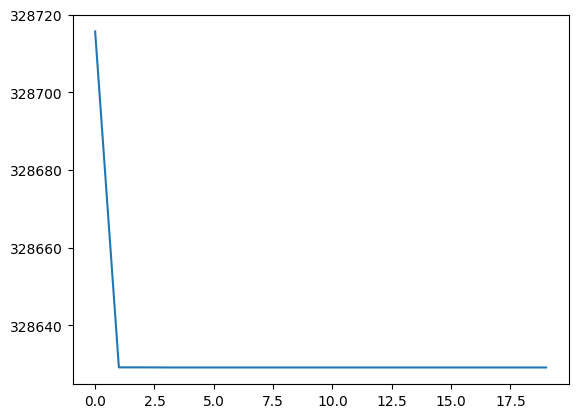

In [ ]:
plt.plot(mycebmf21.obj)

<Axes: >

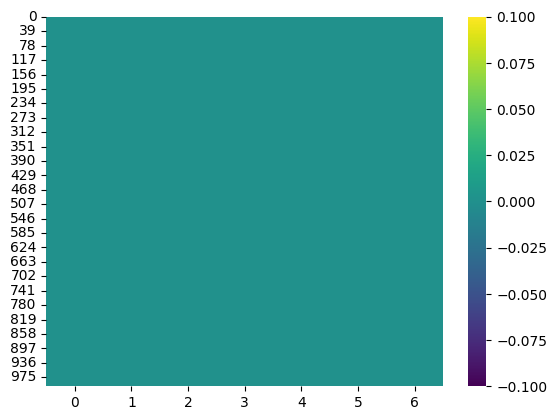

In [14]:
sns.heatmap(
     L,
     cmap="viridis",
     annot=False 
) 

In [17]:
N = 2000  
P= 200
# Scatter of x vs y 
torch.manual_seed(i)

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------

t0 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t1 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t11 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t12 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t21 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t22 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1

a0 = t0 * torch.randn(P)
b1 = t1 * torch.randn(P)
b2 = t2 * torch.randn(P)
detla11= t11 *torch.randn(P)

detla12= t11 *torch.randn(P)
detla21= t11 *torch.randn(P)
detla22= t11 *torch.randn(P)  
f_mat = torch.stack([a0,b1,b2, detla11, detla12,detla21, detla22 ], dim=0)
N= 1000

L = torch.zeros(N, 7, dtype=torch.float32)
L[:,0]= torch.randint(0, 2, (N,), dtype=torch.float32)
L[:,1]= torch.randint(0, 2, (N,), dtype=torch.float32)
L[:,2]= torch.randint(0, 2, (N,), dtype=torch.float32)
L[:,3]= torch.randint(0, 2, (N,), dtype=torch.float32)
L[:,4]= torch.randint(0, 2, (N,), dtype=torch.float32)
    
L[ :,5]= torch.randint(0, 2, (N,), dtype=torch.float32)

 
X_true= L@f_mat 
Z = L@f_mat +  torch.randn(N, P)      # (N, M)
Z_np = Z.detach().cpu().numpy()
     

<Axes: >

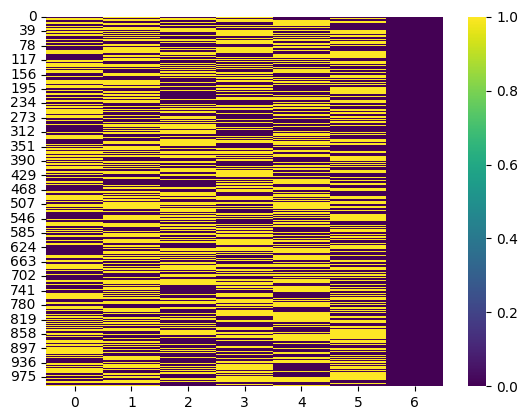

In [18]:
sns.heatmap(
     L,
     cmap="viridis",
     annot=False 
) 